# Step 1: Machine Learning Models

## Task 1.1 — Load and Explore

- [ ] Load the dataset with pandas and print the first few rows
- [ ] Check the shape (number of rows and columns)
- [ ] Check for missing values — fill or drop them
- [ ] Check class balance: are there roughly equal numbers of each label?
- [ ] If one class has far more samples than the other, note this and use F1-score as your main metric

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the training data from a CSV file
df = pd.read_csv("data/train.csv")

In [3]:
# Display the first few rows of the DataFrame
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
# Display the shape of the DataFrame
print(df.shape)

(891, 12)


In [5]:
# Display summary information about the DataFrame, including data types and non-null counts
print(df.info())

# Handle missing values in the 'Age' column by filling them with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop the 'Cabin' column since it has a large number of missing values and may not provide useful information for the model
df = df.drop(columns=['Cabin'])

# Handle missing values in the 'Embarked' column by filling them with the mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


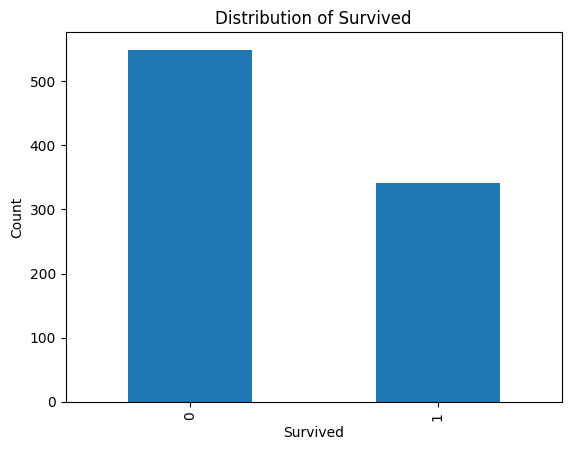

In [6]:
# Display the distribution as percentages
print(df['Survived'].value_counts(normalize=True))

# Visualize the distribution of the 'Survived' column using a bar plot
df['Survived'].value_counts().plot(kind='bar')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Distribution of Survived')
plt.show()

##### The dataset is mildly imbalanced — 62% did not survive, and 38% survived. I will use the F1 Score as my primary metric to account for this.

In [7]:
# Identify categorical columns in the DataFrame
print(df.select_dtypes(include=['object']).columns)

# Drop 'Name', 'Ticket' and 'PassengerId' columns.
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


## Task 1.2 — Prepare the Data

- [ ] Separate features (X) and label (y)
- [ ] Split the data into training (80%) and testing (20%) sets using `random_state=42`

> **Remember**: Always use fit_transform() on the training set and transform() on the test set. Never fit the TF-IDF on test data — that is called data leakage.

In [8]:
# Separate features (X) and label (y)
X = df.drop(columns='Survived')  # Everything except the label
y = df['Survived']  # Only the label

In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Task 1.3 — Train and Compare Models

- [ ] Train at least 3 models: e.g. Logistic Regression, Random Forest, KNN
- [ ] For each model report: accuracy, precision, recall, F1-score
- [ ] Plot a confusion matrix for each model
- [ ] Put all results in one summary table and choose the best model — explain your choice

> **Tip**: Put all model results in one summary table so they are easy to compare side by side.

In [10]:
from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neighbors import KNeighborsClassifier # K-Nearest Neighbors

from sklearn.pipeline import Pipeline # For creating a pipeline of transformations and model
from sklearn.preprocessing import StandardScaler # For feature scaling

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Evaluation metrics

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # For confusion matrix visualization

Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1 Score: 0.7244094488188977


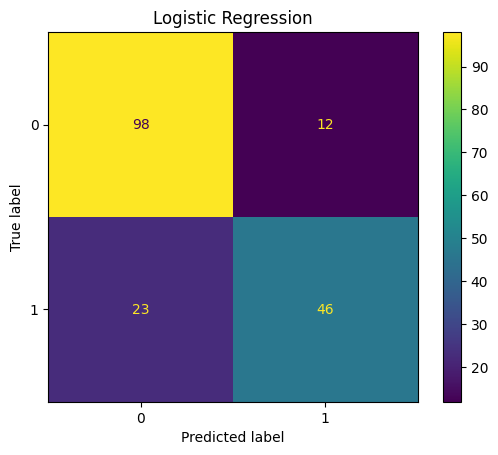

In [11]:
# Create a pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('model', LogisticRegression(random_state=42)) # Logistic Regression model
])
# Fit the pipeline to the training data
lr_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate the model using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# Visualize the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression")
plt.show()

Accuracy: 0.8156424581005587
Precision: 0.78125
Recall: 0.7246376811594203
F1 Score: 0.7518796992481203


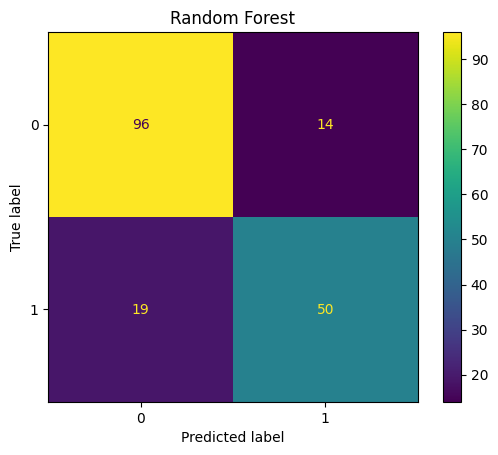

In [12]:
# Train a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model's performance using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

# Visualize the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest")
plt.show()

Accuracy: 0.8156424581005587
Precision: 0.8
Recall: 0.6956521739130435
F1 Score: 0.7441860465116279


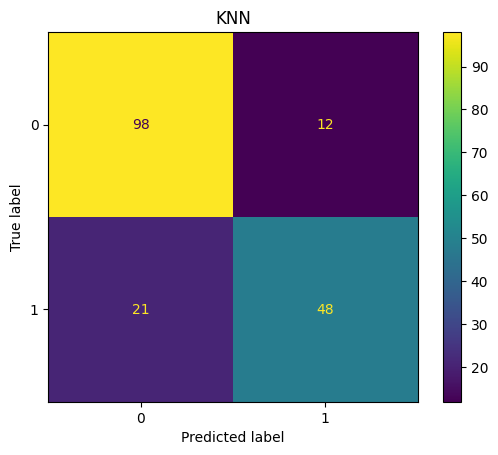

In [13]:
# Train a K-Nearest Neighbors classifier with feature scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Feature scaling
    ('model', KNeighborsClassifier(n_neighbors=5))  # KNN model
])
# Fit the pipeline to the training data
knn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate the model using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

# Visualize the confusion matrix for K-Nearest Neighbors
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN")
plt.show()

In [14]:
# Compile the results of all three models into a DataFrame for easy comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409
1        Random Forest  0.815642   0.781250  0.724638  0.751880
2                  KNN  0.815642   0.800000  0.695652  0.744186


### Model Selection — Best Model: Random Forest

Random Forest was selected as the best model, achieving the highest accuracy (81.6%) 
and F1 score (0.752) among all three models. Since the dataset has a mild class 
imbalance, the F1 score is the most important metric, and Random Forest leads in this 
regard. KNN matched it on accuracy and edged it on precision (0.800 vs 0.781), but fell 
behind on recall and F1. Logistic Regression was a close third, while KNN ranked second 
overall.

---

# Step 2: Neural Network

## Task 2.1 — Build and Train

- [ ] Build a neural network using Keras Dense layers with ReLU and Sigmoid/Softmax
- [ ] Add at least one Dropout layer to reduce overfitting
- [ ] Train for at least 10 epochs
- [ ] Plot the training vs. validation loss and accuracy curves

> **Remember**: If training accuracy keeps going up but validation accuracy goes down, your model is overfitting. Try increasing Dropout or reducing layers.

In [15]:
import tensorflow as tf # For setting the random seed (reproducibility)
from tensorflow.keras.models import Sequential # For creating a sequential model
from tensorflow.keras.layers import Input, Dense, Dropout # For adding layers to the model

In [16]:
# Set a random seed so weight initialisation and dropout are reproducible across runs
tf.keras.utils.set_random_seed(42)

model = Sequential([
    # Define the input layer with the shape of the training data
    Input(shape=(X_train.shape[1],)),

    # First hidden layer with dropout regularization
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Second hidden layer with dropout regularization
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model with binary cross-entropy loss and the Adam optimizer
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Compile the model with the Adam optimizer, binary cross-entropy loss function, and accuracy as a metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

scaler = StandardScaler()

# Scale the training and testing data using the StandardScaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model on the scaled training data with a validation split of 20%, for 10 epochs, and a batch size of 32
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6538 - loss: 0.6504 - val_accuracy: 0.7552 - val_loss: 0.6030
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7311 - loss: 0.5770 - val_accuracy: 0.7413 - val_loss: 0.5505
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7909 - loss: 0.5277 - val_accuracy: 0.7413 - val_loss: 0.5136
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7680 - loss: 0.5154 - val_accuracy: 0.7622 - val_loss: 0.4927
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7909 - loss: 0.4825 - val_accuracy: 0.7902 - val_loss: 0.4791
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7979 - loss: 0.4641 - val_accuracy: 0.7832 - val_loss: 0.4701
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7891 - loss: 0.4616 - val_accuracy: 0.7832 - val_loss: 0.4643
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7996 - loss: 0.4550 - val_accuracy: 0.7832 - val

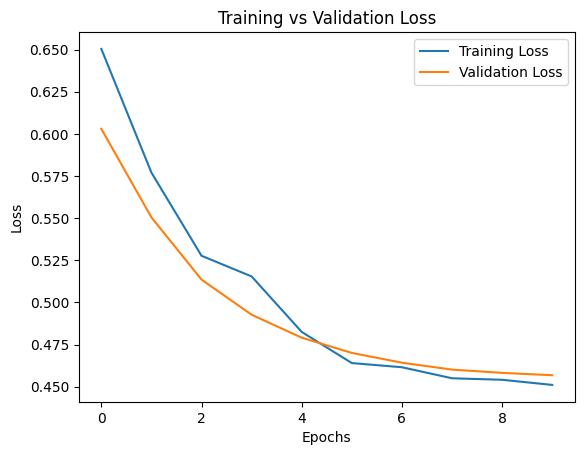

In [18]:
# Plot the training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Set the title of the plot to "Training vs Validation Loss", and label the axes accordingly
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

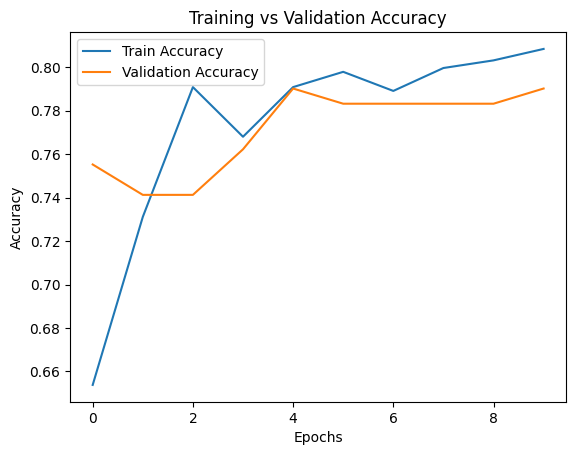

In [19]:
# Plot the training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Set the title of the plot to "Training vs Validation Accuracy", and label the axes accordingly
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Task 2.2 — Compare with Step 1

- [ ] Evaluate the neural network on the test set using the same metrics as Step 1
- [ ] Add the neural network results to your summary table from Step 1
- [ ] Write 2–3 sentences explaining whether the neural network was better or worse and why

> **Tip**: Try one improvement: add more layers, change the learning rate, or add more Dropout — then compare before and after.

In [20]:
# Make predictions on the test set using the trained model
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5).astype(int)

# Evaluate the neural network performance using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Accuracy: 0.8212290502793296
Precision: 0.8135593220338984
Recall: 0.6956521739130435
F1 Score: 0.75


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

# Set the same random seed so the improved model is reproducible too
tf.keras.utils.set_random_seed(42)

# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_improved = Sequential([
    # Define the input layer with the shape of the training data
    Input(shape=(X_train.shape[1],)),


    # First hidden layer with dropout regularization
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Second hidden layer with dropout regularization
    Dense(32, activation='relu'),
    Dropout(0.5),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the improved model with the Adam optimizer, binary cross-entropy loss function, and accuracy as a metric
model_improved.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the improved model on the scaled training data with a validation split of 20%, for 50 epochs, and a batch size of 32
history_improved = model_improved.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Make predictions on the test set using the improved model
y_pred_improved = model_improved.predict(X_test_scaled)
y_pred_improved = (y_pred_improved > 0.5).astype(int)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5940 - loss: 0.6855 - val_accuracy: 0.7413 - val_loss: 0.6189
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6889 - loss: 0.6298 - val_accuracy: 0.7343 - val_loss: 0.5770
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7223 - loss: 0.5770 - val_accuracy: 0.7483 - val_loss: 0.5442
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7188 - loss: 0.5614 - val_accuracy: 0.7552 - val_loss: 0.5212
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7346 - loss: 0.5450 - val_accuracy: 0.7902 - val_loss: 0.5050
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7768 - loss: 0.5177 - val_accuracy: 0.7902 - val_loss: 0.4928
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7803 - loss: 0.5171 - val_accuracy: 0.7762 - val_loss: 0.4829
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7786 - loss: 0.5043 - val_accuracy: 0.7902 - v

In [22]:
# Compile the results of all three models into a DataFrame for easy comparison, including the neural network results
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN", "Baseline NN", "Improved NN"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_improved)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_improved)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_improved)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_improved)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409
1        Random Forest  0.815642   0.781250  0.724638  0.751880
2                  KNN  0.815642   0.800000  0.695652  0.744186
3          Baseline NN  0.821229   0.813559  0.695652  0.750000
4          Improved NN  0.793296   0.785714  0.637681  0.704000


### Neural Network Comparison — Baseline Nearly Tied Random Forest; Tuning Did Not Help

The baseline neural network performed strongly, reaching an F1 score of 0.750 — essentially tied with Random Forest (0.752) — and the highest accuracy of any model (0.821). The "improved" version, which raised Dropout from 0.3 to 0.5 and added Early Stopping, actually performed worse, with its F1 score falling from 0.750 to 0.704. The heavier Dropout likely removed too much capacity for such a small dataset, so the extra regularisation hurt rather than helped. Random Forest remained the best model on F1, but the simple baseline network was a very close competitor.